# Calorie Burn Prediction – Garmin Case Study
## Machine Learning Fallstudie | Hochschule Reutlingen
### Modul: Artificial Intelligence | Prof. Dr. Alexander Rossmann

## Importing the relevant libraries

In [1]:
# Importing libraries with the import command
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sns.set()

## Loading the raw data

In [2]:
# Load the data from a .csv file in the same folder
# Objective: Predict calorie burn based on biometric and training features
df = pd.read_csv('gym_members_exercise_tracking.csv')

# Display the top 5 rows of the data file
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
# Get an overview of the dataset structure
# Shows column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

### Exploring the descriptive statistics of the variables

In [4]:
# Descriptive statistics are useful for initial exploration of the variables
df.describe(include='all')

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973,973.000000,973.000000,973.000000,973.000000,973.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,NaN,NaN,NaN,NaN,NaN
freq,NaN,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,NaN,NaN,NaN,NaN,NaN
mean,38.683453,NaN,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,NaN,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,NaN,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,NaN,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,NaN,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,NaN,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,NaN,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,NaN,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,NaN,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,NaN,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,NaN,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,NaN,29.300000,3.100000,4.000000,2.000000,28.560000


### Data Cleansing – Checking for missing values and duplicates

In [5]:
# The command isnull() shows whether a data point is missing
# True = missing, False = not missing
df.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [6]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

### Data Cleansing – Encoding categorical variables

In [7]:
# Encode the categorical variable 'Gender' as binary
# Male = 1, Female = 0
df['Gender_encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Create dummy variables for 'Workout_Type'
# drop_first=True avoids multicollinearity (dummy variable trap)
df = pd.get_dummies(df, columns=['Workout_Type'], drop_first=True)

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_encoded,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20,1,False,False,True
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00,0,True,False,False
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71,0,False,False,False
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41,1,False,True,False
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39,1,False,True,False


## Checking the OLS assumptions – Visualisation

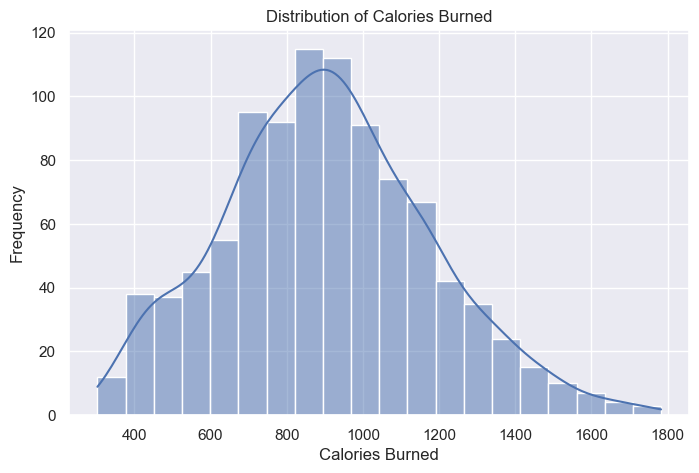

In [8]:
# The distribution shows how Calories_Burned is spread across the dataset
plt.figure(figsize=(8, 5))
sns.histplot(df['Calories_Burned'], bins=20, kde=True)

plt.title('Distribution of Calories Burned')
plt.xlabel('Calories Burned')
plt.ylabel('Frequency')

plt.show()

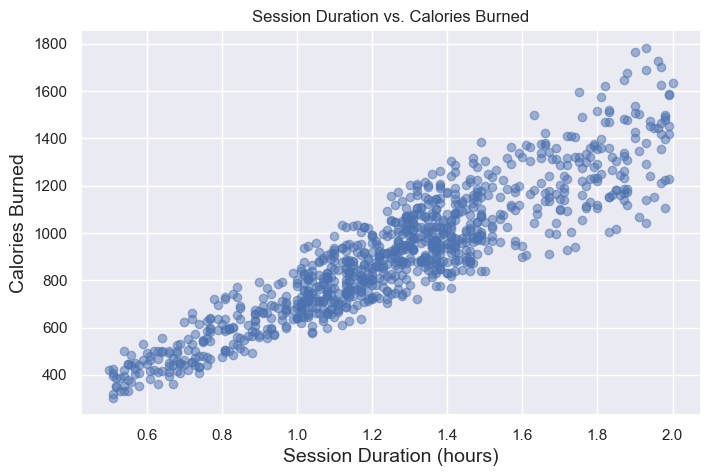

In [9]:
# Check the relationship between Session_Duration and Calories_Burned
# A linear relationship would confirm suitability for linear regression
plt.figure(figsize=(8, 5))
plt.scatter(df['Session_Duration (hours)'], df['Calories_Burned'], alpha=0.5)

plt.xlabel('Session Duration (hours)', size=14)
plt.ylabel('Calories Burned', size=14)
plt.title('Session Duration vs. Calories Burned')

plt.show()

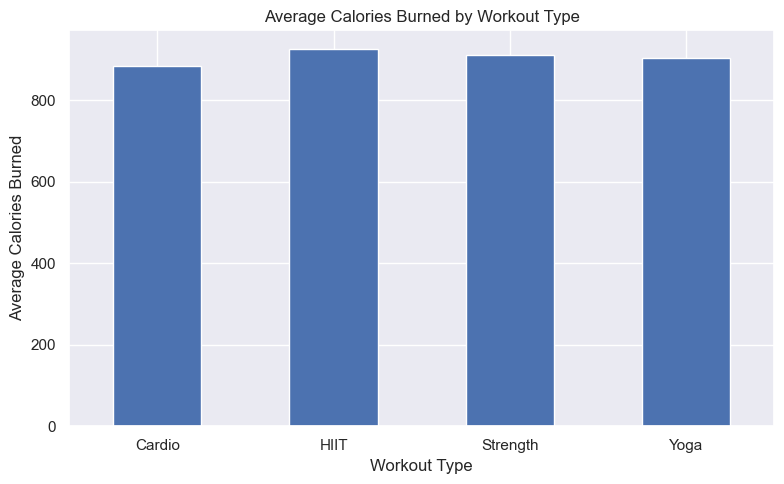

In [10]:
# Average calorie burn by workout type
df_original = pd.read_csv('gym_members_exercise_tracking.csv')
avg_calories = df_original.groupby('Workout_Type')['Calories_Burned'].mean()

avg_calories.plot(kind='bar', figsize=(8, 5))

plt.title('Average Calories Burned by Workout Type')
plt.xlabel('Workout Type')
plt.ylabel('Average Calories Burned')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Declare the inputs and the target

In [11]:
# The target (dependent variable) is 'Calories_Burned'
targets = df['Calories_Burned']

# The inputs are all relevant biometric and training features
# Gender (original) is dropped since we use Gender_encoded instead
inputs = df.drop(columns=['Calories_Burned', 'Gender'])

print('Input features:', list(inputs.columns))
print('Number of features:', inputs.shape[1])

Input features: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Gender_encoded', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga']
Number of features: 16


### Train Test Split

In [12]:
# Split into 80% training and 20% test data
# random_state ensures reproducibility of results
x_train, x_test, y_train, y_test = train_test_split(
    inputs, targets, test_size=0.2, random_state=42
)

print('Training set:', x_train.shape)
print('Test set:', x_test.shape)

Training set: (778, 16)
Test set: (195, 16)


## Linear Regression Model

In [13]:
# Train the Multiple Linear Regression model on the training data
reg = LinearRegression()
reg.fit(x_train, y_train)

LinearRegression()

In [14]:
# Calculate predictions on the test data
y_hat = reg.predict(x_test)

# Evaluate the model with R² and MAE
print(f'Linear Regression R²:  {r2_score(y_test, y_hat):.3f}')
print(f'Linear Regression MAE: {mean_absolute_error(y_test, y_hat):.2f} kcal')

Linear Regression R²:  0.980
Linear Regression MAE: 30.27 kcal


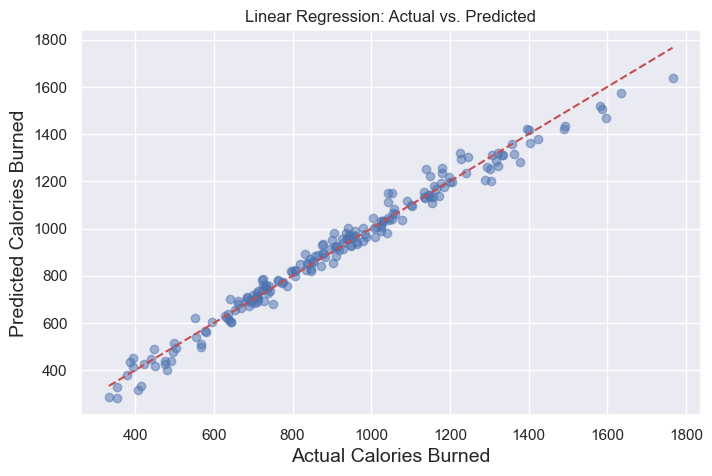

In [15]:
# Plot actual vs. predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_hat, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel('Actual Calories Burned', size=14)
plt.ylabel('Predicted Calories Burned', size=14)
plt.title('Linear Regression: Actual vs. Predicted')

plt.show()

### Feature Weights – Linear Regression

In [16]:
# Show the weight of each feature in the linear regression model
reg_summary = pd.DataFrame(inputs.columns.values, columns=['Features'])
reg_summary['Weights'] = reg.coef_
reg_summary.sort_values(by='Weights', ascending=False)

,Features,Weights
6,Session_Duration (hours),712.813300
2,Height (m),108.168013
12,Gender_encoded,82.597321
4,Avg_BPM,6.157881
9,Workout_Frequency (days/week),3.957690
11,BMI,3.360187
5,Resting_BPM,0.603316
3,Max_BPM,0.108806
7,Fat_Percentage,-0.643731
1,Weight (kg),-1.005983


## Random Forest Model

In [17]:
# Train a Random Forest with 100 decision trees
# Random Forest can capture non-linear relationships between features and target
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
# Calculate predictions on the test data
y_hat_rf = rf.predict(x_test)

# Evaluate the Random Forest on test data
print(f'Random Forest R²:  {r2_score(y_test, y_hat_rf):.3f}')
print(f'Random Forest MAE: {mean_absolute_error(y_test, y_hat_rf):.2f} kcal')

Random Forest R²:  0.973
Random Forest MAE: 36.49 kcal


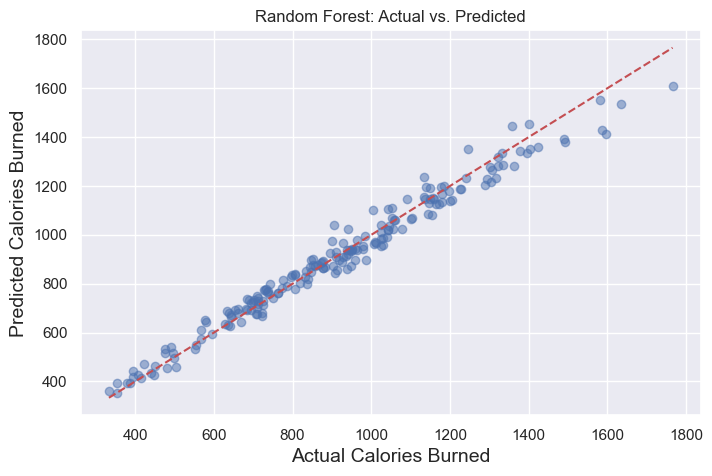

In [19]:
# Plot actual vs. predicted values for Random Forest
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_hat_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel('Actual Calories Burned', size=14)
plt.ylabel('Predicted Calories Burned', size=14)
plt.title('Random Forest: Actual vs. Predicted')

plt.show()

## Deployment – Example Prediction

In [20]:
# Predict calorie burn for a sample person using Linear Regression
# Age: 24, Weight: 63kg, Height: 1.67m, Duration: 1.5h, Female, Cardio
new_person = pd.DataFrame([{
    'Age': 24,
    'Height (m)': 1.67,
    'Weight (kg)': 63,
    'Max_BPM': 177,
    'Avg_BPM': 134,
    'Resting_BPM': 68,
    'Session_Duration (hours)': 1.5,
    'Fat_Percentage': 25,
    'Water_Intake (liters)': 2.0,
    'Workout_Frequency (days/week)': 3,
    'Experience_Level': 2,
    'BMI': 22.6,
    'Gender_encoded': 0,
    'Workout_Type_HIIT': False,
    'Workout_Type_Strength': False,
    'Workout_Type_Yoga': False
}])

# Reorder columns to match training data exactly
new_person = new_person[inputs.columns]

pred_lr = reg.predict(new_person)
print(f'Linear Regression – Predicted Calorie Burn: {pred_lr[0]:.2f} kcal')

Linear Regression – Predicted Calorie Burn: 1028.63 kcal


In [21]:
# Predict calorie burn for the same person using Random Forest
pred_rf = rf.predict(new_person)
print(f'Random Forest – Predicted Calorie Burn: {pred_rf[0]:.2f} kcal')

Random Forest – Predicted Calorie Burn: 974.71 kcal


## Evaluation

In [22]:
# Calculate evaluation metrics for both models
mae_lr = mean_absolute_error(y_test, y_hat)
r2_lr  = r2_score(y_test, y_hat)
mae_rf = mean_absolute_error(y_test, y_hat_rf)
r2_rf  = r2_score(y_test, y_hat_rf)

print('Multiple Lineare Regression')
print(f'MAE: {mae_lr:.2f}')
print(f'R²:  {r2_lr:.3f}')

print('\nRandom Forest Regressor')
print(f'MAE: {mae_rf:.2f}')
print(f'R²:  {r2_rf:.3f}')

Multiple Lineare Regression
MAE: 30.27
R²:  0.980

Random Forest Regressor
MAE: 36.49
R²:  0.973


In [23]:
# Compare both models side by side in a table
results = pd.DataFrame({
    'Modell': ['Multiple Lineare Regression', 'Random Forest Regressor'],
    'MAE':   [round(mae_lr, 2), round(mae_rf, 2)],
    'R²':    [round(r2_lr, 3), round(r2_rf, 3)]
})

results

,Modell,MAE,R²
0,Multiple Lineare Regression,30.27,0.980
1,Random Forest Regressor,36.49,0.973


### Feature Importance – Random Forest

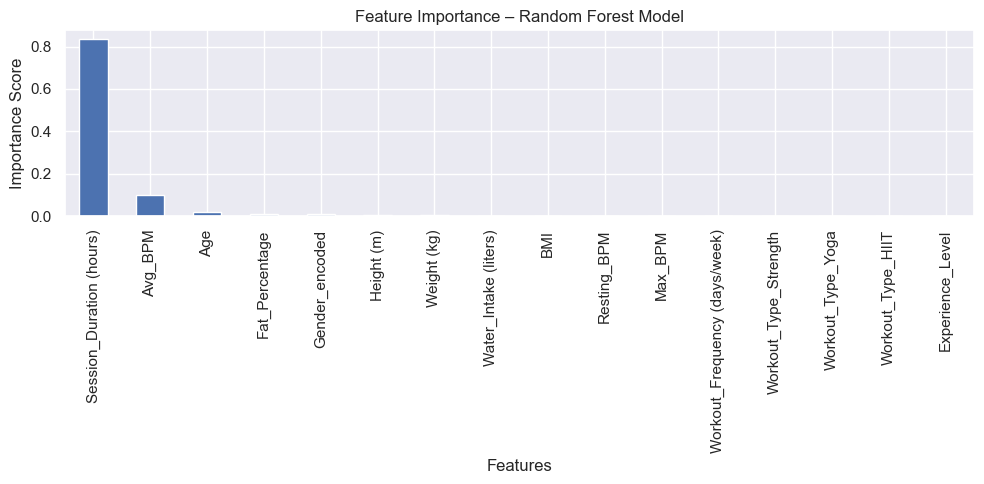

In [24]:
# Random Forest provides feature importance scores
# This shows which features have the most influence on the prediction
importance = pd.Series(rf.feature_importances_, index=x_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar')

plt.title('Feature Importance – Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.tight_layout()
plt.show()

In [25]:
# Show the top 5 most important features
top5 = importance.head(5)

print(top5)

Session_Duration (hours)    0.834091
Avg_BPM                     0.099814
Age                         0.019254
Fat_Percentage              0.012652
Gender_encoded              0.011245
dtype: float64


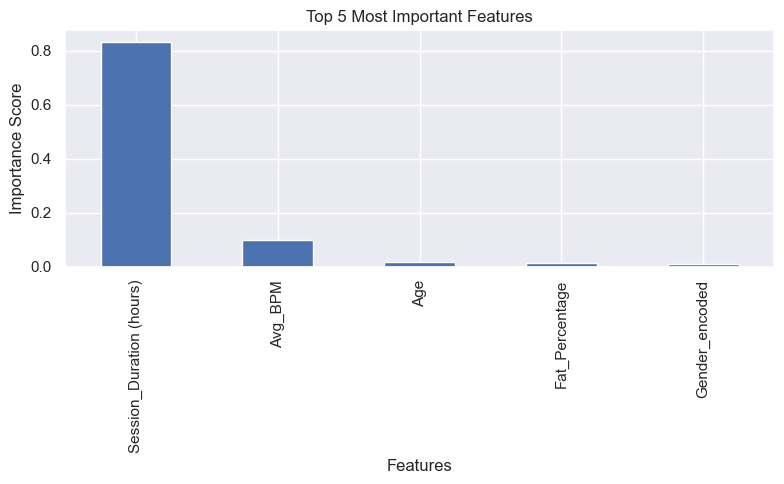

In [26]:
# Visualise the top 5 most important features
top5 = importance.head(5)

plt.figure(figsize=(8, 5))
top5.plot(kind='bar')

plt.title('Top 5 Most Important Features')
plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.tight_layout()
plt.show()